# Expectation-maximization algorithm

## Introduction

In this exercise you will segment three tissue classes in an MR image based on a generative model which you will fit to the image data. You will perform the Expectation-Maximization algorithm to fit the model parameters.
The MR data for this exercise consists of a 2-dimensional slice of a brain scan in the axial
orientation. The file _segmentData.mat_ contains the original slice as well as a mask that excludes
non-brain tissues such as eyeballs, fat, skin, etc. The file _correctedData.mat_ contains the same
image, but after it has been corrected for the MR bias field artifact using the method described in
section 3.5. It is this image you will be modeling.

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

### Input data and code hints
Import Python libraries:

In [37]:
import numpy as np
import scipy
from scipy.io import loadmat
from scipy import signal
import warnings
warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import math
%matplotlib inline

## Task 1: Image data
Display the image provided in "correctedData.mat" and plot its histogram.

> ***Hints:***
> - .mat data can be loaded in python as follows
>   
>       mat = loadmat("correctedData.mat")
> 
>       data = mat["correctedData"]
>
> - Use 100 bins for your histogram
> - The mask sets all background pixels to zero. Disregard the background pixels by clipping 0.

(array([  0.,   0.,   1.,   5.,  11.,  35.,  38.,  55.,  69., 130., 154.,
        200., 215., 239., 215., 201., 195., 197., 154., 154., 154., 133.,
        150., 131., 111., 143., 132., 120., 145., 149., 179., 161., 209.,
        205., 246., 266., 305., 337., 346., 328., 361., 353., 330., 315.,
        315., 282., 314., 266., 275., 276., 283., 307., 276., 335., 352.,
        377., 424., 453., 391., 287., 169., 116.,  73.,  51.,  21.,  13.,
         13.,   7.,   5.,   6.,   3.,   0.,   1.,   1.,   1.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  1.        ,   6.48666935,  11.9733387 ,  17.46000805,
         22.9466774 ,  28.43334675,  33.9200161 ,  39.40668545,
         44.8933548 ,  50.38002415,  55.8666935 ,  61.35336285,
         66.8400322 ,  72.32670155,  77.8133709 ,  83.30004025,
         88.7867096 ,  94.27337895,  99.7600483 , 105.24671765

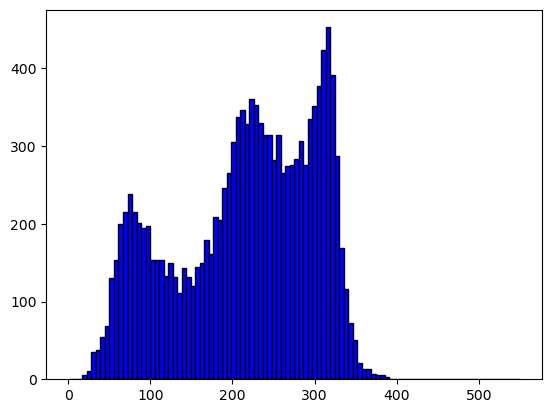

In [38]:
mat = loadmat("correctedData.mat")
data = mat["correctedData"]
data[data == 1 ] = 0
nan = np.where(np.isnan(data), 0, data)
max = np.nanmax(data)
min = np.nanmin(data)


plt.hist(data.ravel(), bins=100, range = (1, max), color='blue', edgecolor='black')




## Task 2: Initialize Gaussian-Mixture Model
Compute the minimum and maximum intensity in the image (non-zero pixels), and divide the
intensity range up into three equally wide intervals. Initialize the parameters of a 3-component
Gaussian mixture model by setting the means of the Gaussians to the centers of the intensity
intervals, the variances to the square of the width of the intervals, and the prior weights to $\frac{1}{3}$ each.

> ***Hint:***
> - In your intensity range, disregard the background pixels by clipping 0

In [39]:
data_f = data.copy()
data_f= data_f[data_f > 0]
max_rm = np.nanpercentile(data_f, 99)
min = np.nanmin(data_f)

interval_width = (max_rm - min) / 3

mu = np.array([min + interval_width/2, min + 3*interval_width/2, min + 5*interval_width/2])
sigma = np.array([interval_width, interval_width, interval_width])
pi = np.array([0.22, 0.30, 0.48])

print("Initial means:", mu)
print("Initial variances:", sigma)
print("Initial weights:", pi)


Initial means: [ 71.83133647 181.33759938 290.84386229]
Initial variances: [109.50626291 109.50626291 109.50626291]
Initial weights: [0.22 0.3  0.48]


## Task 3: Display inital Gaussian distributions
Overlay the resulting Gaussian mixture model on the histogram by plotting each
Gaussian weighted by its $\pi_k$, as well as the total weighted sum of all three Gaussian distributions
(as in fig. 3.1(b) in the course notes).

> ***Hint:***
> - A gaussian distribution with the parameters $\mu$, $\sigma^2$, scaled by the weight $w$ and evaluated at positions $x$ can be obtained by the function
>        
>        w * scipy.stats.norm.pdf( x, mu, sigma).
>
> - you can use the bin edges of your histogram as $x$.

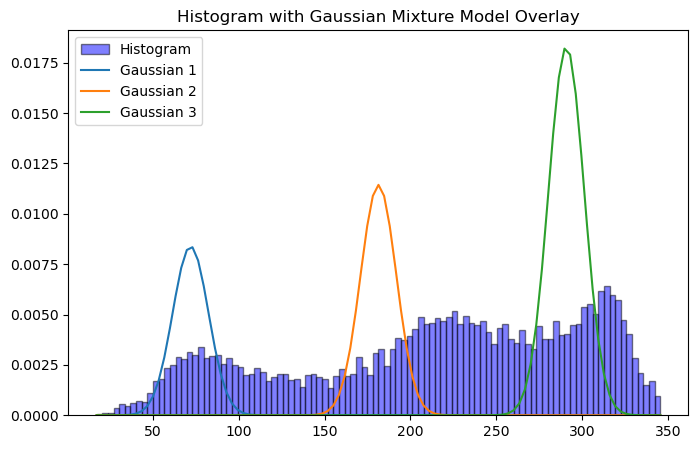

In [40]:

hist, bin_edges = np.histogram(data_f, bins=100, range=(min, max_rm), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))
plt.hist(data_f, bins=100, range=(min, max_rm), color='blue', edgecolor='black', alpha=0.5, density=True, label='Histogram')

gmm_sum = np.zeros_like(bin_edges)
for k in range(3):
    gaussian = pi[k] * norm.pdf(bin_edges, mu[k], np.sqrt(sigma[k]))
    plt.plot(bin_edges, gaussian, label=f'Gaussian {k+1}')
    gmm_sum += gaussian

plt.legend()
plt.title('Histogram with Gaussian Mixture Model Overlay')
plt.show()

## Task 4: Compute weights
Compute the values of ${w}_{n,k}$ defined by:

$$ \mathcal{w}_{n,k} = \frac{\mathcal{N}(d_n \vert \tilde{\mu}_k, \tilde{\sigma}^2_k) \tilde{\pi}_k}{\sum^K_{k'=1} \mathcal{N}(d_n \vert \tilde{\mu}_k', \tilde{\sigma}^2_{k'}) \tilde{\pi}_k'}. $$

Visualize the values of each ${w}_{n,k}$ in a figure. You should have three plots which each display only the pixels that belong to the respective class, according to the weights.

> ***Hint:***
> - The segmentation of a pixel is determined by assigning the class of the highest probability. 
> - In your visualization, disregard the background pixels by clipping 0

(240, 160)


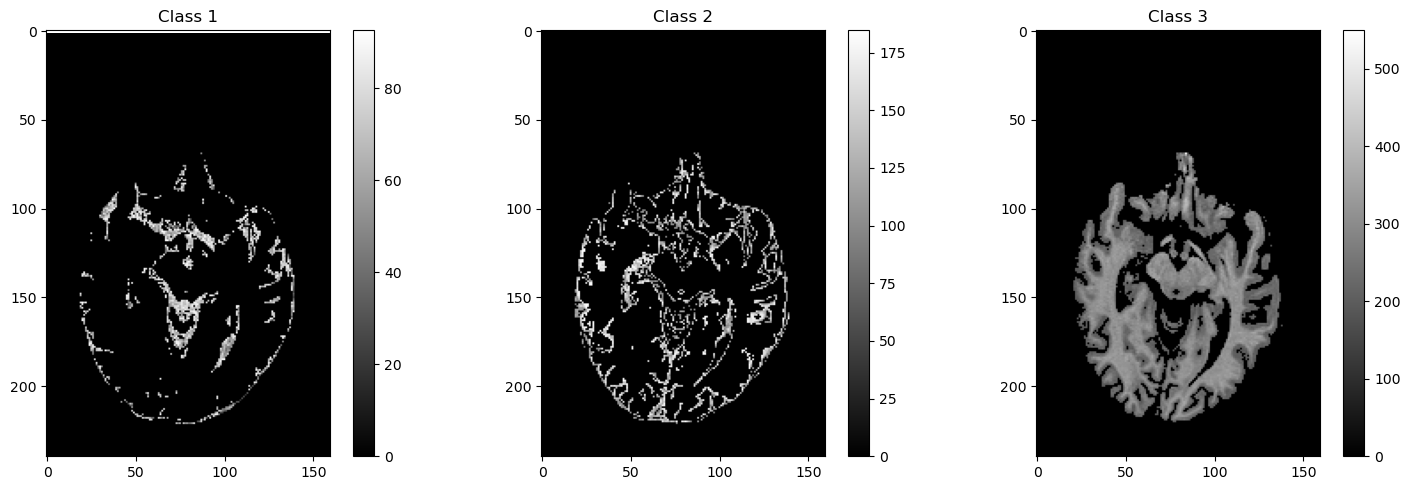

In [41]:
K = 3
print(data.shape)
H, W = data.shape

likelihoods = np.zeros((H, W, K))

for k in range(K):
    likelihoods[:, :, k] = norm.pdf(data, loc=mu[k], scale=sigma[k])

numerator = likelihoods * pi

denominator = np.sum(numerator, axis=2, keepdims=True)

w = np.divide(numerator,  denominator, out = np.zeros_like(numerator), where=denominator!=0)

plt.figure(figsize=(15, 5))

for k in range(K):
    plt.subplot(1, 3, k+1)
    # Argmax to find the pixel with the maximum prob for that k class
    mask = np.argmax(w, axis=2) == k
    img = np.where(mask, data, 0)
    plt.imshow(img, cmap='gray')
    plt.title(f'Class {k+1}')
    plt.colorbar()

plt.tight_layout()
plt.show()

## Task 5: Estimate Maximum Likelihood parameters
Estimate the maximum likelihood parameters by iterating between updating the model parameter
estimate according to 

$$ \tilde{\mu_k} \leftarrow \frac{\sum^N_{n=1} w_{n,k} d_n}{\sum^N_{n=1} w_{n,k}}  $$

$$ \tilde{\sigma}^2_k \leftarrow \frac{\sum^N_{n=1} w_{n,k} (d_n - \tilde{\mu_k})^2}{\sum^N_{n=1} w_{n,k}}  $$

$$ \tilde{\pi_k} \leftarrow \frac{\sum^N_{n=1} w_{n,k}}{N}  $$

and by recomputing ${w}_{n,k}$ according to eq. 3.33 (see Task 4).

Make sure to perform enough iterations (e.g., 100) for the algorithm to converge. As the iterations progress, plot
the evolution of the log likelihood function, and update each time the display of ${w}_{n,k}$ as well as
the Gaussian mixture model plot overlaid on the histogram. Include the evolution of the log
likelihood function and the plot of the final ${w}_{n,k}$ and the final mixture model in your report.

> ***Hint:***
> - The log likelihood can be simply computed by
>       $\log ( \sum_k w_k x_k )$

In [42]:
import numpy.ma as ma
class GMM:
    def __init__(self, n_iterations=100, k=3):
        """
        Initiate class
        Defines imported variables

        Parameter
        ---------
        self: 
            object to store variables and functions

        n_iterations: 
            Number of iteration before termination
        
        k:
            Number of class to estimate with gaussians 

        """
        self.n_iter = n_iterations
        self.k = k

        self.mu = None
        self.sigma = None
        self.pi = None

        self.log_likelihood_history = []
        self.last_w = None
        self.eps = 1e-12

    def init_param(self, data):
        """
        Initiates parameters
            Flatten data, pi, mu, sigma, min, max and max_rm of the data
        
        Parameters
        -----------
        Self

        date: 
            Any HxW data
        """

        self.flat_data = data[data>0]
        N = len(self.flat_data)

        self.pi = np.ones(self.k)/self.k

        sample = np.random.choice(N, self.k, replace=False)
        self.mu = self.flat_data[sample]

        init_var = np.var(self.flat_data)/self.k
        self.sigma = np.ones(self.k) * init_var

        self.min = np.min(self.flat_data)
        self.max = np.max(self.flat_data)
        self.max_rm = np.percentile(self.flat_data, 99)

    def e_step(self, data):
        """ 
        Estiamation step. This step computes the likehood to calculate the weights w and finally computes the totel likelihood and log likelihood

        Parameters
        -----------

        self

        data

        Returns
        -----------
        w:
            Computed weights
        
        Log likelihood:
            The total log likelihood of this step
        """
        H, W = data.shape
        log_comp = np.zeros((self.k, H, W))
        
        for k in range(self.k):
            log_pdf = norm.logpdf(data, loc=self.mu[k], scale=np.sqrt(self.sigma[k]))
            log_comp[k, :, :] = np.log(self.pi[k] + self.eps) + log_pdf
        m = np.max(log_comp, axis=0, keepdims=True) # shape (1, H, W)
        log_sum_exp = m + np.log(np.sum(np.exp(log_comp - m), axis=0, keepdims=True) + self.eps)
        
        # w = exp( log(numerator) - log(denominator) )
        w = np.exp(log_comp - log_sum_exp) # shape (K, H, W)
        log_likelihood = np.sum(log_sum_exp[0, data > 0]) 
        w = w.transpose(1, 2, 0) # from (K, H, W) to (H, W, K)
        
        self.last_w = w
        return w, float(log_likelihood)
    
    def m_step(self, data, w):
        """
        Maximization step: updates the parameters mu, sigma, and pi.
        """
        flat_data_pos = data[data > 0]
        w_pos = w[data > 0]
        N_pos = len(flat_data_pos)

        for k in range(self.k):
            w_k = w_pos[:, k]
            w_k_sum = np.sum(w_k)

            self.mu[k] = np.sum(w_k * flat_data_pos) / w_k_sum
            self.sigma[k] = np.sum(w_k * (flat_data_pos - self.mu[k]) ** 2) / w_k_sum
            self.pi[k] = w_k_sum / N_pos

    def fit(self, data):
        
        self.init_param(data)

        for i in range(self.n_iter):
            w, log_likelihood = self.e_step(data)
            self.log_likelihood_history.append(log_likelihood)
            self.m_step(data, w)

        return self
    
    def plot_convergence(self):
        """Plots the log-likelihood history to show convergence."""
        if not self.log_likelihood_history:
            print("Model has not been fitted yet. Run .fit(data) first.")
            return

        plt.figure(figsize=(8, 5))
        plt.plot(self.log_likelihood_history, marker='o', linestyle='-', color='blue')
        plt.title(f'Log-Likelihood Convergence (K={self.k})')
        plt.xlabel('Iteration')
        plt.ylabel('Log-Likelihood')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
        
    def plot_segmentation_components(gmm_model, data):
        """
        Plots the hard segmentation masks for each component (K=3).
        """
        # get segmentation
        # shape (H, W) where each value is 0, 1, or 2
        segmentation_map = np.argmax(gmm_model.last_w, axis=2) 
        
        background_mask = (data <= 0)

        fig, axes = plt.subplots(1, gmm_model.k, figsize=(15, 5))

        for k in range(gmm_model.k):
            ax = axes[k]
            
            # one if pixel belongs to component k
            binary_mask = (segmentation_map == k)
            
            # only show the segmented tissue (data > 0)
            plot_data = ma.array(binary_mask.astype(int), mask=background_mask)

            cmap = plt.cm.gray.copy()
            cmap.set_bad('black')

            im = ax.imshow(plot_data, cmap=cmap, vmin=0, vmax=1)
            
            mu_val = gmm_model.mu[k]
            ax.set_title(f'Comp {k} Hard Mask: $\\mu$={mu_val:.2f}')
            ax.axis('off')
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    def plot_responsibilities(self, data):
        if self.last_w is None:
            print("Model has not been fitted yet. Run .fit(data) first.")
            return

        total = self.k + 1
        ncols = 3 if total > 3 else (2 if total > 1 else 1)
        nrows = int(np.ceil(total / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
        axes = np.array(axes).flatten()

        axes[0].imshow(data, cmap='gray')
        axes[0].set_title('Original')
        axes[0].axis('off')

        mask = (data <= 0)
        cmap = plt.cm.get_cmap('gray_r').copy()
        cmap.set_bad('black')

        for idx in range(self.k):
            ax = axes[idx + 1]
            im = ax.imshow(ma.array(self.last_w[:, :, idx], mask=mask), cmap=cmap, vmin=0, vmax=1)
            ax.set_title(f'Comp {idx}: μ={self.mu[idx]:.2f}, σ={self.sigma[idx]:.2f}')
            ax.axis('off')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for ax in axes[total:]:
            fig.delaxes(ax)

        plt.tight_layout()
        plt.show()

    def plot_segmentation(self, data):
        """
        Plots the original image and GMM segmentation side-by-side.
        """
        if self.last_w is None:
            print("Model has not been fitted yet. Run .fit(data) first.")
            return
        
        # Create side-by-side plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot original data
        ax1.imshow(data, cmap='gray')
        ax1.set_title('Original Data')
        
        # Create segmentation map
        seg_map = np.argmax(self.last_w, axis=2)
        mask = (data <= 0)
        masked_seg = ma.array(seg_map, mask=mask)
        
        # Plot segmentation with meaningful colors
        cmap = plt.cm.get_cmap('viridis', self.k)
        cmap.set_bad(color='black')
        im = ax2.imshow(masked_seg, cmap=cmap)
        ax2.set_title('GMM Segmentation')
        
        # Add colorbar with component info
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_ticks(range(self.k))
        cbar.set_ticklabels([f'μ={self.mu[i]:.1f}' for i in range(self.k)])
        
        plt.tight_layout()
        plt.show()

    def plot_hist(self):
        """Plots histogram of data with GMM component overlay"""
        plt.figure(figsize=(8, 5))
        
        # Plot histogram of data
        plt.hist(self.flat_data, bins=50, range=(self.min, self.max_rm), 
                density=True, alpha=0.5, color='gray', edgecolor='black')

        # Plot GMM components
        x = np.linspace(self.min, self.max_rm, 200)
        total = np.zeros_like(x)
        for k in range(self.k):
            component = self.pi[k] * norm.pdf(x, self.mu[k], np.sqrt(self.sigma[k]))
            plt.plot(x, component, label=f'Component {k+1}')
            total += component
        
        plt.plot(x, total, 'r--', label='Mixture')
        plt.title('Data Histogram w gaussians')
        plt.legend()
        plt.show()

In [43]:
gmm = GMM(n_iterations=100, k=3)
gmm.fit(data)
gmm.e_step
print("Final Means (mu):", gmm.mu)
print("Final Variances (sigma):", gmm.sigma)
print("Final Mixing Coefficients (pi):", gmm.pi)



Final Means (mu): [312.36557964  84.30716056 228.13828572]
Final Variances (sigma): [ 245.73710562  665.45692898 2816.97527906]
Final Mixing Coefficients (pi): [0.18288612 0.19640502 0.62070886]


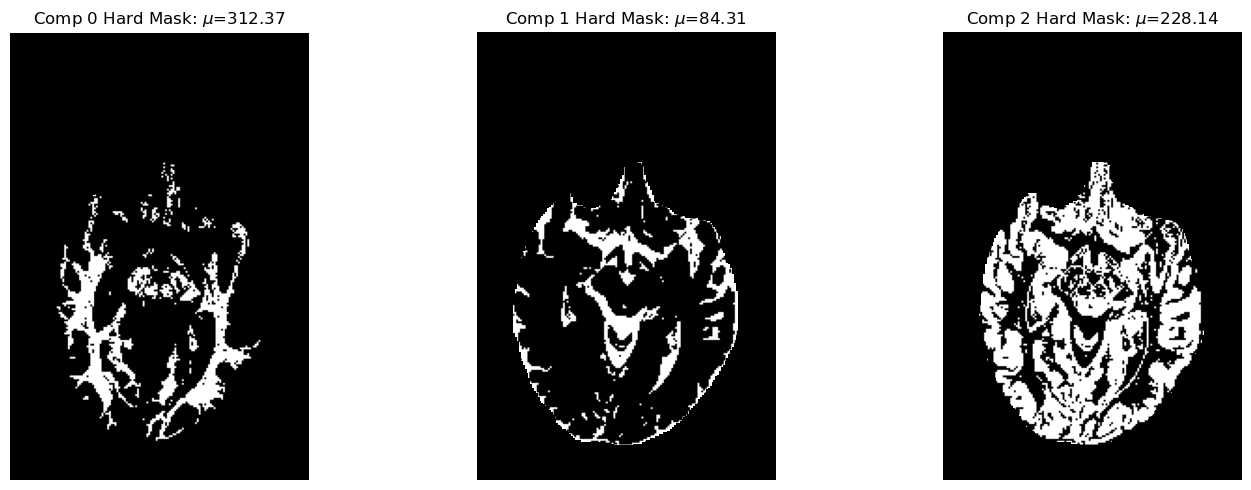

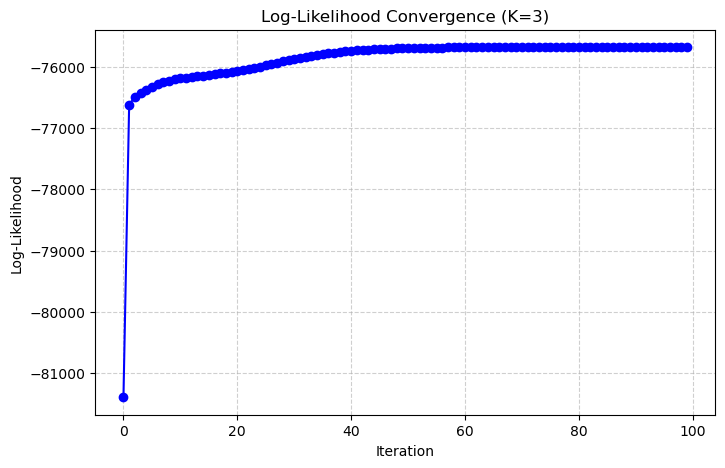

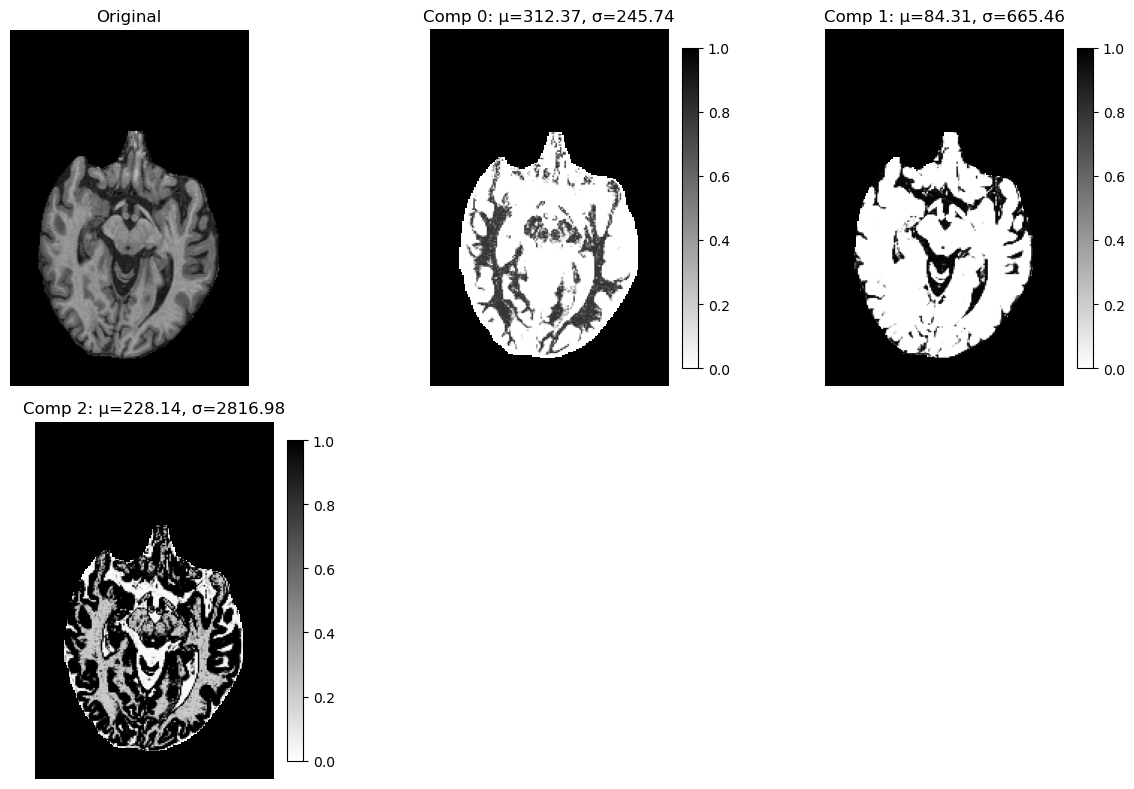

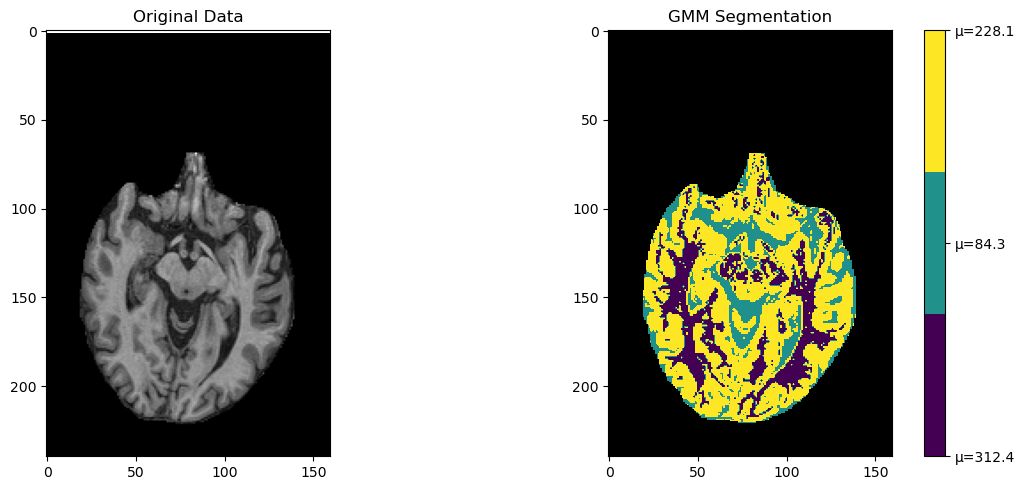

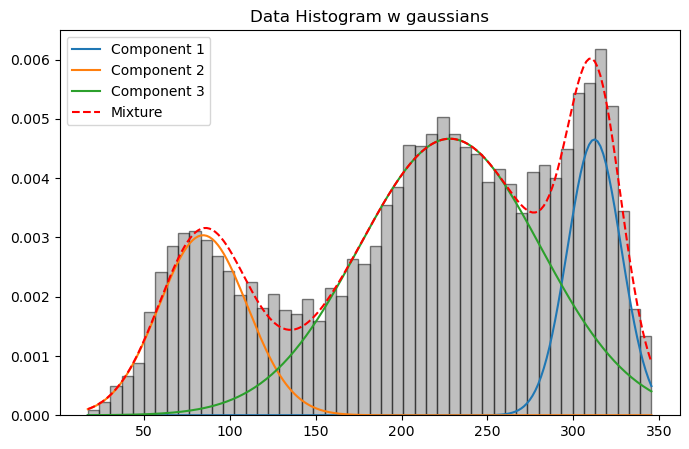

In [44]:
gmm.plot_segmentation_components(data)
gmm.plot_convergence()
gmm.plot_responsibilities(data)
gmm.plot_segmentation(data)
gmm.plot_hist()

## Task 6: Vary only one model parameter
Keeping all other parameters fixed to their estimated values, vary only $\mu_2$ (the mean of the middle
Gaussian distribution) between the estimated values of $\mu_1$ and $\mu_3$ in about 100 steps, and plot for
each step the log likelihood function.

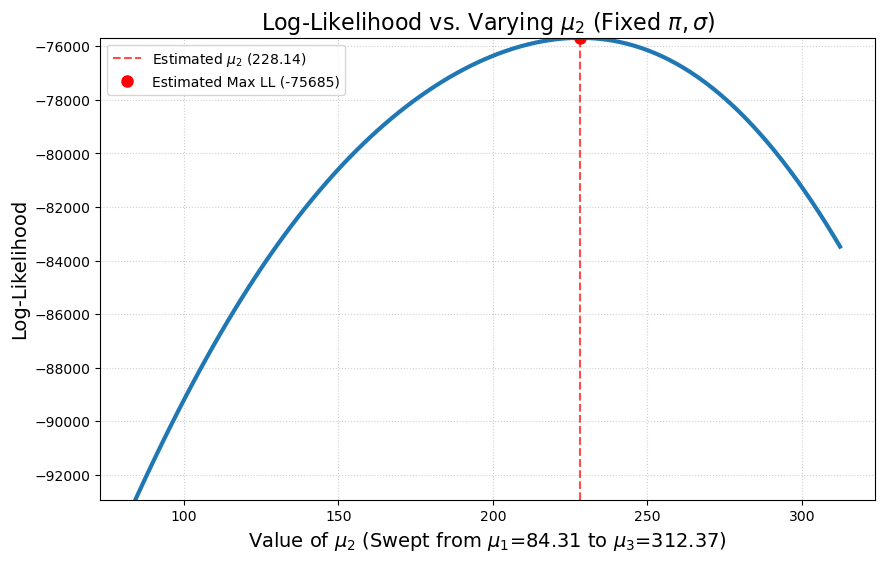

In [58]:

def vary_one_param(gmm, data, n_iter = 100):
    sorted = np.argsort(gmm.mu)
    
    eps = 1e-12
    mu_min = gmm.mu[sorted[0]]
    mu_max = gmm.mu[sorted[2]]

    mu2_idx = sorted[1]
    mu2_esti = gmm.mu[mu2_idx]

    mu_space = np.linspace(mu_min, mu_max, n_iter)
    H, W = data.shape
    log_likelihoods = []

    fix_mu= gmm.mu.copy()
    fix_sigma = gmm.sigma.copy()
    fix_pi = gmm.pi.copy()

    log_ref = gmm.log_likelihood_history[-1] if gmm.log_likelihood_history else None

    for mu in mu_space:
        H, W = data.shape
        temp_mu = fix_mu.copy()
        temp_mu[mu2_idx] = mu
        likelihoods = np.zeros((H, W, gmm.k))

        for k in range(gmm.k):
            log_pdf = norm.logpdf(data, loc=temp_mu[k], scale=np.sqrt(fix_sigma[k]))
            likelihoods[:, :, k] = np.log(fix_pi[k] + eps) + log_pdf
        
        m = np.max(likelihoods, axis=-1, keepdims=True) # shape (H, W, 1)
        log_sum_exp = m + np.log(np.sum(np.exp(likelihoods - m), axis=-1, keepdims=True) + eps)

        w = np.exp(likelihoods - log_sum_exp) # shape (K, H, W)
        w = w.transpose(1, 2, 0) # from (K,
        log_likelihood = np.sum(log_sum_exp[data > 0])
        log_likelihoods.append(log_likelihood)
    min_ll_sweep = np.min(log_likelihoods)
    max_ll_sweep = np.max(log_likelihoods)

    plt.figure(figsize=(10, 6))
    plt.plot(mu_space, log_likelihoods, color='#1f77b4', linewidth=3)
    

    buffer = 10 
    plt.ylim(min_ll_sweep - buffer, max_ll_sweep + buffer/2) 
    
    plt.axvline(mu2_esti, color='red', linestyle='--', alpha=0.7, 
                label=f'Estimated $\\mu_2$ ({mu2_esti:.2f})')
    
    if log_ref is not None:
        plt.plot(mu2_esti, log_ref, 'o', color='red', markersize=8, 
                 label=f'Estimated Max LL ({log_ref:.0f})') 

    plt.title(f'Log-Likelihood vs. Varying $\\mu_2$ (Fixed $\\pi, \\sigma$)', fontsize=16)
    plt.xlabel(f'Value of $\\mu_2$ (Swept from $\\mu_1$={mu_min:.2f} to $\\mu_3$={mu_max:.2f})', fontsize=14)
    plt.ylabel('Log-Likelihood', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

vary_one_param(gmm, data)

## Task 7: Locate Lower bound
On the same figure, also plot the lower bound corresponding to the parameter vector in which all
parameters are set to their estimated values, except $\mu_2$ which is set to the estimated value of $\mu_1$.

## Task 8: Maximize lower bound
Compute the value for $\mu_2$ that maximizes this lower bound (first line of eq. 3.35), indicate its location
on the figure, and comment on the result.

Formulate the lower bound as 

$$ Q(\theta \vert \tilde{\theta}) = -\frac{1}{2} \sum^K_{k=1} [\frac{1}{\sigma^2_k} \sum^N_{n=1} w_{n,k} (d_n - \mu_k - \sum^M_{m-1} c_m \phi_{n,m})^2 + (\sum^N_{n-1} w_{n,k}) \log \sigma^2_k] $$

$$ + \sum^K_{k=1} [(\sum^N_{n=1} w_{n,k}) \log \pi_k] $$

$$ - \sum^N_{n=1} \sum^K_{k=1} w_{n,k} \log w_{n,k} - \frac{N}{2} \log (2\pi) $$
